
1. LOADING OCCUPANCY BLOCKS TABLE
   Rows: 83
   Columns: 103
   Occupancy range: 0 - 79
   Date range: 2026-02-09 - 2026-03-19

2. IDENTIFYING SENSOR COLUMNS
   Sensor columns found: 96
      Corridor_CO2_Increment_max
      Corridor_CO2_Increment_mean
      Corridor_CO2_Increment_min
      Corridor_CO2_Increment_std
      Corridor_CO2_max
      Corridor_CO2_mean
      Corridor_CO2_min
      Corridor_CO2_std
      Corridor_Humidity_Increment_max
      Corridor_Humidity_Increment_mean
      Corridor_Humidity_Increment_min
      Corridor_Humidity_Increment_std
      Corridor_Humidity_max
      Corridor_Humidity_mean
      Corridor_Humidity_min
      Corridor_Humidity_std
      Corridor_Temp_Increment_max
      Corridor_Temp_Increment_mean
      Corridor_Temp_Increment_min
      Corridor_Temp_Increment_std
      Corridor_Temperature_max
      Corridor_Temperature_mean
      Corridor_Temperature_min
      Corridor_Temperature_std
      Hanging_CO2_Increment_max
      Hanging_CO2_Incremen

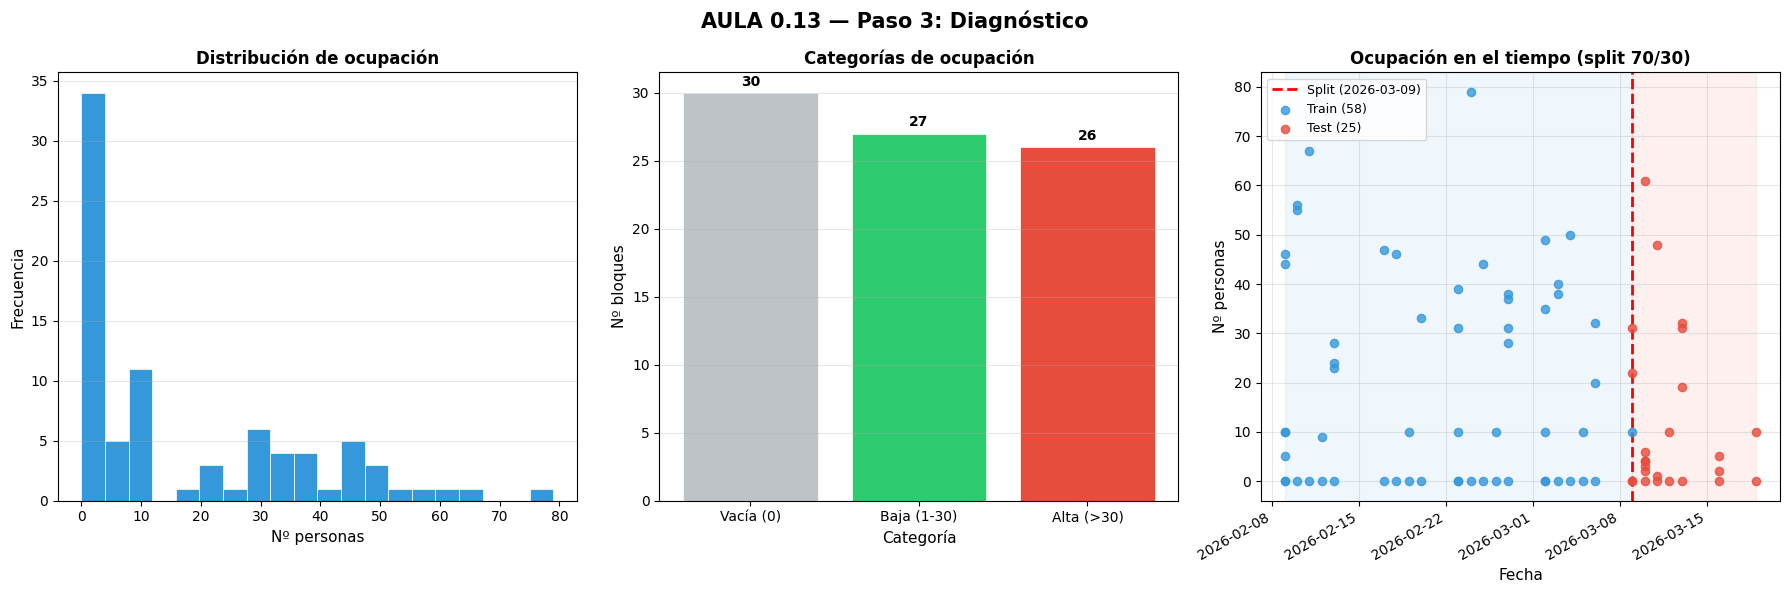

   ✓ diagnostico_general.png


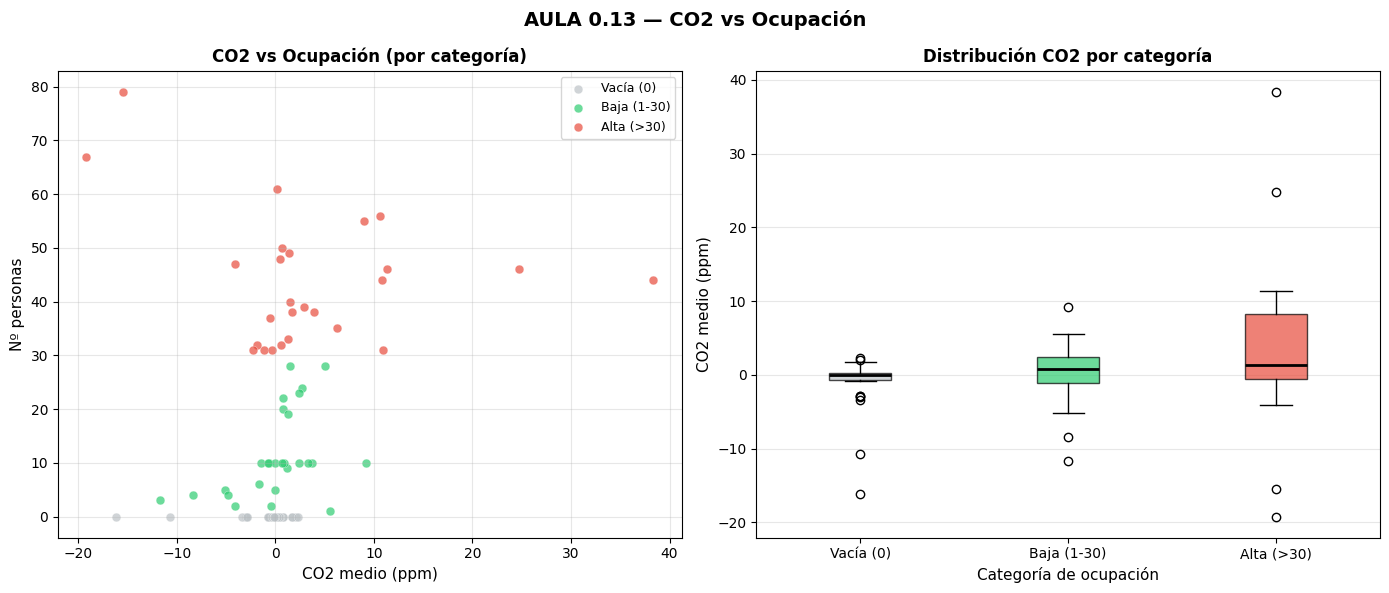

   ✓ co2_vs_occupancy.png


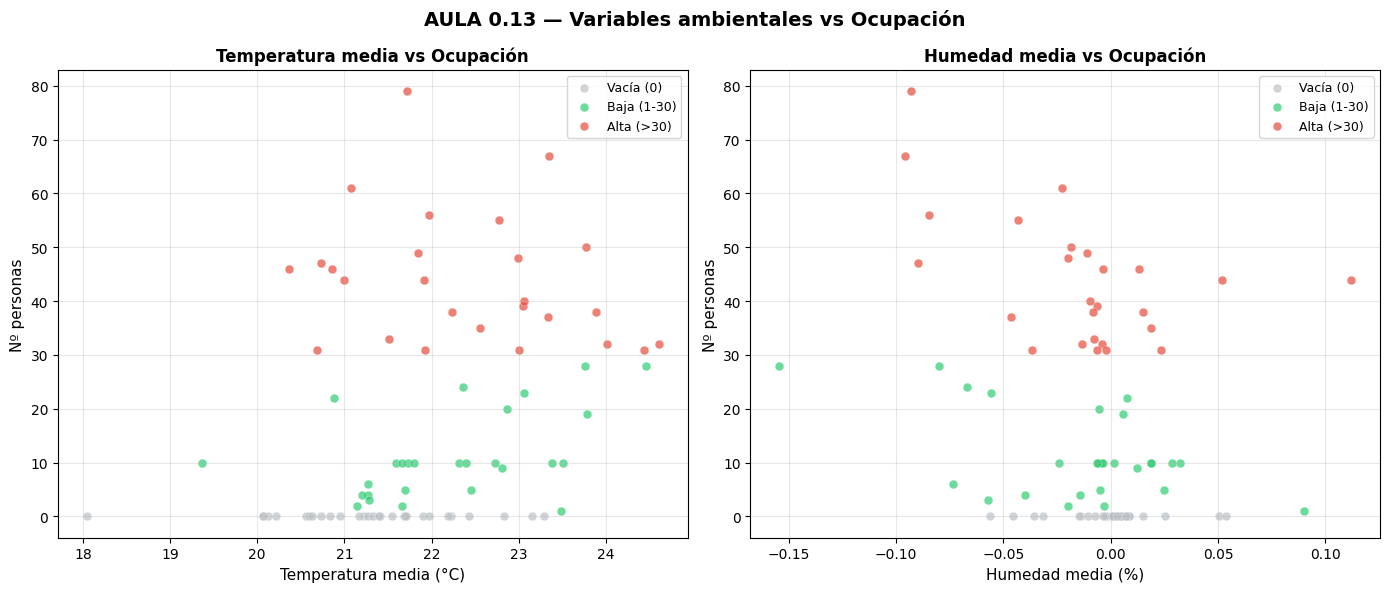

   ✓ temp_hum_vs_occupancy.png

   Generando gráficas de distribución de categorías...


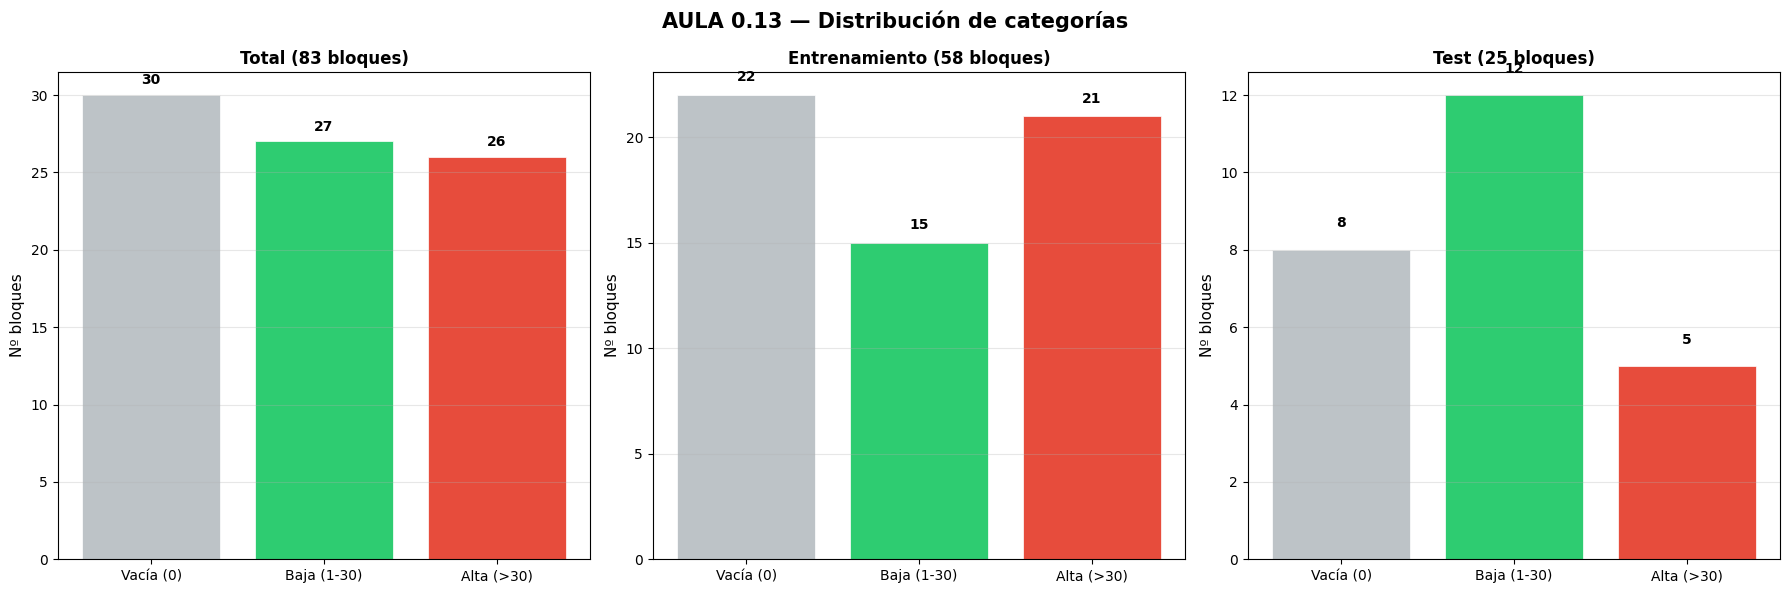

   ✓ distribucion_categorias_absolutas.png


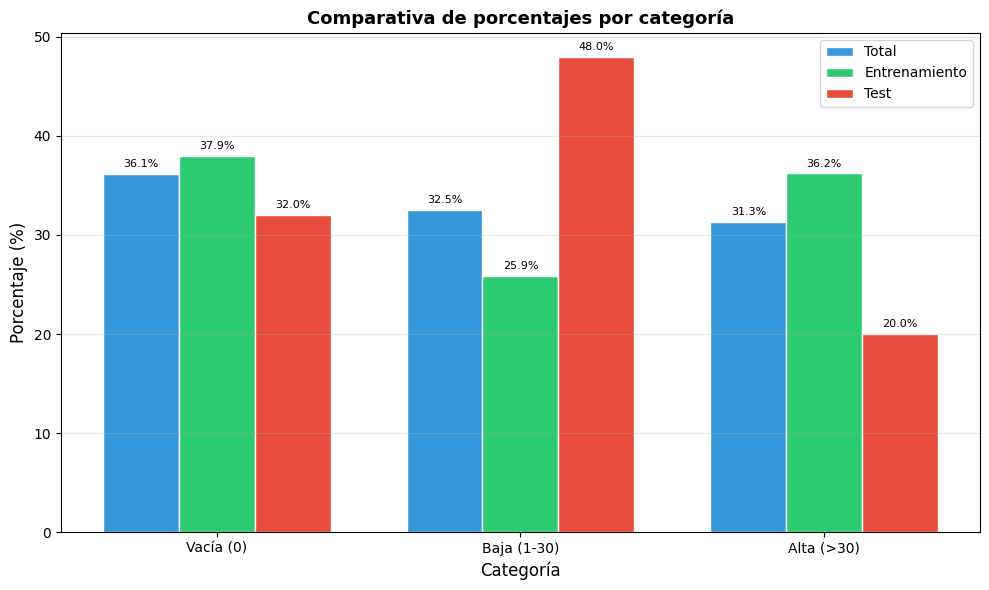

   ✓ distribucion_categorias_porcentajes.png

✅ Paso 3 completado con gráficos mejorados!

Archivos generados en: ml_features_grouped/
   • X_train.xlsx, X_test.xlsx
   • y_train_regression.xlsx, y_test_regression.xlsx
   • train_blocks.xlsx, test_blocks.xlsx, all_blocks.xlsx
   • sensor_cols.pkl
   • diagnostico_general.png
   • co2_vs_occupancy.png
   • temp_hum_vs_occupancy.png
   • distribucion_categorias_absolutas.png
   • distribucion_categorias_porcentajes.png

¡Listo para la fase de modelado!


In [1]:
#!/usr/bin/env python3
# ===================================================================
# SISTEMA DE ANÁLISIS AMBIENTAL PARA AULA 0.13 
# ===================================================================
# AUTOR: Carmen Gómez Alarcón (adaptación)
# FECHA: 2026
# FASE: Paso 3. Transformación de bloques de ocupación en matrices X/y
#       con división temporal 70/30 y gráficos de diagnóstico mejorados.
# ===================================================================

import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Directorio de salida
OUTPUT_DIR = 'ml_features_grouped'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ===================================================================
# 1. CARGA DE DATOS
# ===================================================================
print("\n" + "="*60)
print("1. LOADING OCCUPANCY BLOCKS TABLE")
print("="*60)

INPUT_FILE = 'occupancy_analysis/013_occupancy_blocks_analysis.xlsx'
if not os.path.exists(INPUT_FILE):
    print(f"ERROR: File not found: {INPUT_FILE}")
    exit()

df = pd.read_excel(INPUT_FILE)
df['Date'] = pd.to_datetime(df['Date'])

print(f"   Rows: {len(df)}")
print(f"   Columns: {len(df.columns)}")
print(f"   Occupancy range: {df['Occupancy'].min():.0f} - {df['Occupancy'].max():.0f}")
print(f"   Date range: {df['Date'].min().date()} - {df['Date'].max().date()}")

# ===================================================================
# 2. IDENTIFICACIÓN DE COLUMNAS DE SENSORES (mejorada)
# ===================================================================
print("\n" + "="*60)
print("2. IDENTIFYING SENSOR COLUMNS")
print("="*60)

non_feature_cols = ['Occupancy', 'Date', 'Day_of_Week', 'Start_Time',
                    'End_Time', 'Duration_min', 'Week']

# Filtramos columnas que terminan en _mean, _std, _max, _min
sensor_cols = [c for c in df.columns
               if c not in non_feature_cols
               and any(c.endswith(s) for s in ['_mean', '_std', '_max', '_min'])]

print(f"   Sensor columns found: {len(sensor_cols)}")
for col in sensor_cols:
    print(f"      {col}")

# ===================================================================
# 3. LIMPIEZA Y PREPARACIÓN DEL DATAFRAME
# ===================================================================
print("\n" + "="*60)
print("3. PREPARING FEATURE DATAFRAME")
print("="*60)

df_grouped = df[['Occupancy', 'Date', 'Day_of_Week'] + sensor_cols].copy()

# Eliminamos filas con más del 50% de NaNs en sensores
nan_ratio = df_grouped[sensor_cols].isna().mean(axis=1)
df_grouped = df_grouped[nan_ratio < 0.5].reset_index(drop=True)
df_grouped = df_grouped.sort_values('Date').reset_index(drop=True)

print(f"   Samples after cleaning: {len(df_grouped)}")
print(f"   Date range: {df_grouped['Date'].min().date()} - {df_grouped['Date'].max().date()}")

# ===================================================================
# 4. DIVISIÓN TEMPORAL 70/30 (sin solapamiento)
# ===================================================================
print("\n" + "="*60)
print("4. TEMPORAL SPLIT (70/30)")
print("="*60)

split_idx = int(len(df_grouped) * 0.7)
df_train   = df_grouped.iloc[:split_idx].copy()
df_test    = df_grouped.iloc[split_idx:].copy()
split_date = df_train['Date'].max()

print(f"   Total samples:    {len(df_grouped)}")
print(f"   Training samples: {len(df_train)} ({len(df_train)/len(df_grouped)*100:.1f}%)")
print(f"   Test samples:     {len(df_test)}  ({len(df_test)/len(df_grouped)*100:.1f}%)")
print(f"   Split date:       {split_date.date()}")

# ===================================================================
# 5. CONSTRUCCIÓN DE MATRICES X E Y (REGRESIÓN)
# ===================================================================
print("\n" + "="*60)
print("5. CREATING X AND Y MATRICES (regression)")
print("="*60)

X_train = df_train[sensor_cols].values
X_test  = df_test[sensor_cols].values
y_train = df_train['Occupancy'].values
y_test  = df_test['Occupancy'].values

print(f"   X_train shape: {X_train.shape}")
print(f"   X_test shape:  {X_test.shape}")
print(f"   y_train: {len(y_train)} samples")
print(f"   y_test:  {len(y_test)} samples")

# ===================================================================
# 6. GUARDAR EN ARCHIVOS .xlsx (igual que en el primer script)
# ===================================================================
print("\n" + "="*60)
print("6. SAVING DATA (.xlsx)")
print("="*60)

# Matrices X e y
pd.DataFrame(X_train, columns=sensor_cols).to_excel(
    os.path.join(OUTPUT_DIR, 'X_train.xlsx'), index=False)
pd.DataFrame(X_test, columns=sensor_cols).to_excel(
    os.path.join(OUTPUT_DIR, 'X_test.xlsx'), index=False)
pd.DataFrame({'Occupancy': y_train}).to_excel(
    os.path.join(OUTPUT_DIR, 'y_train_regression.xlsx'), index=False)
pd.DataFrame({'Occupancy': y_test}).to_excel(
    os.path.join(OUTPUT_DIR, 'y_test_regression.xlsx'), index=False)

# Dataframes completos con metadatos
df_train.to_excel(os.path.join(OUTPUT_DIR, 'train_blocks.xlsx'), index=False)
df_test.to_excel(os.path.join(OUTPUT_DIR, 'test_blocks.xlsx'), index=False)
df_grouped.to_excel(os.path.join(OUTPUT_DIR, 'all_blocks.xlsx'), index=False)

# Guardar nombres de features
with open(os.path.join(OUTPUT_DIR, 'sensor_cols.pkl'), 'wb') as f:
    pickle.dump(sensor_cols, f)

print(f"   X_train.xlsx     → {X_train.shape}")
print(f"   X_test.xlsx      → {X_test.shape}")
print(f"   y_train_regression.xlsx → {len(y_train)} filas")
print(f"   y_test_regression.xlsx  → {len(y_test)} filas")
print(f"   train_blocks.xlsx, test_blocks.xlsx, all_blocks.xlsx")
print(f"   sensor_cols.pkl  → {len(sensor_cols)} feature names")

# ===================================================================
# 7. ESTADÍSTICAS BÁSICAS
# ===================================================================
print("\n" + "="*60)
print("7. STATISTICS SUMMARY")
print("="*60)

print(f"\nTraining set:")
print(f"   Occupancy — min: {df_train['Occupancy'].min():.0f}, max: {df_train['Occupancy'].max():.0f}, mean: {df_train['Occupancy'].mean():.2f}")
print(f"   Date range: {df_train['Date'].min().date()} → {df_train['Date'].max().date()}")

print(f"\nTest set:")
print(f"   Occupancy — min: {df_test['Occupancy'].min():.0f}, max: {df_test['Occupancy'].max():.0f}, mean: {df_test['Occupancy'].mean():.2f}")
print(f"   Date range: {df_test['Date'].min().date()} → {df_test['Date'].max().date()}")

# ===================================================================
# 8. GRÁFICAS DE DIAGNÓSTICO (estilo del segundo script, con 3 categorías)
# ===================================================================
print("\n" + "="*60)
print("8. DIAGNOSTIC PLOTS (estilo mejorado)")
print("="*60)

# ---- Definición de categorías (3 niveles) ----
def categorize(val):
    if val == 0:
        return 'Vacía (0)'
    elif val <= 30:
        return 'Baja (1-30)'
    else:
        return 'Alta (>30)'

df_grouped['Category'] = df_grouped['Occupancy'].apply(categorize)
df_train['Category']   = df_train['Occupancy'].apply(categorize)
df_test['Category']    = df_test['Occupancy'].apply(categorize)

cat_order  = ['Vacía (0)', 'Baja (1-30)', 'Alta (>30)']
cat_colors = ['#bdc3c7', '#2ecc71', '#e74c3c']  # gris, verde, rojo

# ------------------------------------------------------------------
# FIGURA 1: Diagnóstico general (3 subplots)
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('AULA 0.13 — Paso 3: Diagnóstico', fontsize=15, fontweight='bold')

# Subplot 1: Distribución de ocupación (histograma)
ax = axes[0]
ax.hist(df_grouped['Occupancy'], bins=20, color='#3498db',
        edgecolor='white', linewidth=0.5)
ax.set_xlabel('Nº personas', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_title('Distribución de ocupación', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Subplot 2: Categorías (barras)
ax = axes[1]
cat_counts = df_grouped['Category'].value_counts().reindex(cat_order).fillna(0)
bars = ax.bar(cat_order, cat_counts.values, color=cat_colors,
              edgecolor='white', linewidth=0.5)
ax.set_xlabel('Categoría', fontsize=11)
ax.set_ylabel('Nº bloques', fontsize=11)
ax.set_title('Categorías de ocupación', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{int(val)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Subplot 3: Ocupación en el tiempo con fondo coloreado
ax = axes[2]
# Fondo coloreado: azul=train, rojo=test
ax.axvspan(df_grouped['Date'].min(), split_date,
           alpha=0.08, color='#3498db', label='_nolegend_')
ax.axvspan(split_date, df_grouped['Date'].max(),
           alpha=0.08, color='#e74c3c', label='_nolegend_')
# Línea de split
ax.axvline(x=split_date, color='red', linestyle='--', lw=2,
           label=f'Split ({split_date.date()})')
# Puntos
ax.scatter(df_train['Date'], df_train['Occupancy'],
           alpha=0.8, s=35, color='#3498db',
           label=f'Train ({len(df_train)})', zorder=3)
ax.scatter(df_test['Date'], df_test['Occupancy'],
           alpha=0.8, s=35, color='#e74c3c',
           label=f'Test ({len(df_test)})', zorder=3)
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Nº personas', fontsize=11)
ax.set_title('Ocupación en el tiempo (split 70/30)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plot1_path = os.path.join(OUTPUT_DIR, 'diagnostico_general.png')
plt.savefig(plot1_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"   ✓ diagnostico_general.png")

# ------------------------------------------------------------------
# FIGURA 2: CO2 vs Occupancy (scatter + boxplot)
# ------------------------------------------------------------------
co2_col = next((c for c in sensor_cols if 'CO2' in c and c.endswith('_mean')), None)

if co2_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('AULA 0.13 — CO2 vs Ocupación', fontsize=14, fontweight='bold')

    ax = axes[0]
    for cat, color in zip(cat_order, cat_colors):
        mask = df_grouped['Category'] == cat
        ax.scatter(df_grouped.loc[mask, co2_col],
                   df_grouped.loc[mask, 'Occupancy'],
                   alpha=0.7, s=40, color=color, label=cat,
                   edgecolors='white', linewidth=0.3)
    ax.set_xlabel('CO2 medio (ppm)', fontsize=11)
    ax.set_ylabel('Nº personas', fontsize=11)
    ax.set_title('CO2 vs Ocupación (por categoría)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    data_by_cat = [df_grouped[df_grouped['Category'] == cat][co2_col].dropna().values
                   for cat in cat_order]
    bp = ax.boxplot(data_by_cat, labels=cat_order, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], cat_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xlabel('Categoría de ocupación', fontsize=11)
    ax.set_ylabel('CO2 medio (ppm)', fontsize=11)
    ax.set_title('Distribución CO2 por categoría', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plot2_path = os.path.join(OUTPUT_DIR, 'co2_vs_occupancy.png')
    plt.savefig(plot2_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"   ✓ co2_vs_occupancy.png")
else:
    print(f"   ⚠ No se encontró columna CO2_mean — omitiendo gráfica CO2")

# ------------------------------------------------------------------
# FIGURA 3: Temperatura y Humedad vs Occupancy
# ------------------------------------------------------------------
temp_col = next((c for c in sensor_cols if 'Temperature' in c
                 and 'Outdoor' not in c and c.endswith('_mean')), None)
hum_col  = next((c for c in sensor_cols if 'Humidity' in c
                 and 'Outdoor' not in c and c.endswith('_mean')), None)

if temp_col or hum_col:
    ncols = sum([temp_col is not None, hum_col is not None])
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6))
    fig.suptitle('AULA 0.13 — Variables ambientales vs Ocupación',
                 fontsize=14, fontweight='bold')
    if ncols == 1:
        axes = [axes]

    idx = 0
    for col, label in [(temp_col, 'Temperatura media (°C)'),
                       (hum_col,  'Humedad media (%)')]:
        if col is None:
            continue
        ax = axes[idx]
        for cat, color in zip(cat_order, cat_colors):
            mask = df_grouped['Category'] == cat
            ax.scatter(df_grouped.loc[mask, col],
                       df_grouped.loc[mask, 'Occupancy'],
                       alpha=0.7, s=40, color=color, label=cat,
                       edgecolors='white', linewidth=0.3)
        ax.set_xlabel(label, fontsize=11)
        ax.set_ylabel('Nº personas', fontsize=11)
        ax.set_title(f'{label.split("(")[0].strip()} vs Ocupación',
                     fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        idx += 1

    plt.tight_layout()
    plot3_path = os.path.join(OUTPUT_DIR, 'temp_hum_vs_occupancy.png')
    plt.savefig(plot3_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"   ✓ temp_hum_vs_occupancy.png")

# ------------------------------------------------------------------
# FIGURA 4: Distribución de categorías (absolutas y porcentajes)
# ------------------------------------------------------------------
print("\n   Generando gráficas de distribución de categorías...")

# Calcular conteos y porcentajes para Total, Train y Test
counts_total = df_grouped['Category'].value_counts().reindex(cat_order).fillna(0)
counts_train = df_train['Category'].value_counts().reindex(cat_order).fillna(0)
counts_test  = df_test['Category'].value_counts().reindex(cat_order).fillna(0)

pct_total = counts_total / counts_total.sum() * 100
pct_train = counts_train / counts_train.sum() * 100
pct_test  = counts_test / counts_test.sum() * 100

# Subfigura 4a: barras apiladas (valores absolutos)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('AULA 0.13 — Distribución de categorías', fontsize=15, fontweight='bold')

for ax, (datos, titulo) in zip(axes, [
    (counts_total, f'Total ({len(df_grouped)} bloques)'),
    (counts_train, f'Entrenamiento ({len(df_train)} bloques)'),
    (counts_test,  f'Test ({len(df_test)} bloques)')
]):
    bars = ax.bar(cat_order, datos.values, color=cat_colors,
                  edgecolor='white', linewidth=0.5)
    ax.set_ylabel('Nº bloques', fontsize=11)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, datos.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{int(val)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distribucion_categorias_absolutas.png'), dpi=200, bbox_inches='tight')
plt.show()
print("   ✓ distribucion_categorias_absolutas.png")

# Subfigura 4b: porcentajes comparativos (barras agrupadas)
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(cat_order))
width = 0.25

bars_total = ax.bar(x - width, pct_total, width, label='Total', color='#3498db', edgecolor='white')
bars_train = ax.bar(x,        pct_train, width, label='Entrenamiento', color='#2ecc71', edgecolor='white')
bars_test  = ax.bar(x + width, pct_test, width, label='Test', color='#e74c3c', edgecolor='white')

ax.set_xlabel('Categoría', fontsize=12)
ax.set_ylabel('Porcentaje (%)', fontsize=12)
ax.set_title('Comparativa de porcentajes por categoría', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(cat_order, fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars_total, bars_train, bars_test]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distribucion_categorias_porcentajes.png'), dpi=200, bbox_inches='tight')
plt.show()
print("   ✓ distribucion_categorias_porcentajes.png")

# ===================================================================
# RESUMEN FINAL
# ===================================================================
print("\n" + "="*60)
print("✅ Paso 3 completado con gráficos mejorados!")
print("="*60)
print(f"\nArchivos generados en: {OUTPUT_DIR}/")
print("   • X_train.xlsx, X_test.xlsx")
print("   • y_train_regression.xlsx, y_test_regression.xlsx")
print("   • train_blocks.xlsx, test_blocks.xlsx, all_blocks.xlsx")
print("   • sensor_cols.pkl")
print("   • diagnostico_general.png")
if co2_col:
    print("   • co2_vs_occupancy.png")
if temp_col or hum_col:
    print("   • temp_hum_vs_occupancy.png")
print("   • distribucion_categorias_absolutas.png")
print("   • distribucion_categorias_porcentajes.png")
print("\n¡Listo para la fase de modelado!")